In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import os
c = 'coral'
c1 = 'yellowgreen'
base_c = 'aqua'

plt.rcParams['text.usetex'] = False
sns.set(style="ticks")
plt.rc('font', family='serif')
#plt.rc('font', serif='Times New Roman')

yaxisfont = 32
bigfont   = 20
medfont   = 20
smallfont = 17

plt.rcParams['xtick.labelsize']=medfont
plt.rcParams['ytick.labelsize']=medfont

#sns.set_style('ticks', {'font.family':'serif', 'font.serif':'Times New Roman', 'font.size': 16})
sns.set_palette("muted")

ticks_fontsize = 18
label_fontsize = 20
cbar_fontsize = 18


### sys-1

### Different Datanumber

In [14]:
import re
import numpy as np

k_ranges = [[1.0, 2.5], [2.5, 5.0], [5.0, 10.0], [10.0, 20.0], [20.0, 30.0], [30.0, 50.0], [50.0, 100.0], [100.0, 200.0]]
lr_range = [0.001] 
sub_sampling_range = [256, 128, 64, 32, 16, 8 ,4, 2]   ##4096, 2048, 1024, 512, 
data_number_range = ['128','256', '512', '1024', '2048', '4096', '8192', '16384']   ###'8', '16', '32', '64',  
seed_range = [2021, 2022, 2023, 2024, 2025] #2020, 2021, 2022, 

bsz = 128


exp_type = 'train'

In [15]:
k_range_list = []
for k_range in k_ranges:
        # 修改成小数点之后如果是 .0可以忽略
        def format_num(x):
            return str(int(x)) if x == int(x) else str(x)
        k_range_list.append(f'{format_num(k_range[0])}-')

In [16]:
exp_stats = {}

In [17]:
for k_range in k_ranges:
    pde_settings = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    exp_stats[pde_settings] = {}
    
    for subsamples in sub_sampling_range:
        for lr in lr_range:

            hyper_settings = f'bsz{bsz}_lr{lr}_subsample{subsamples}'
            
            exp_stats[pde_settings][hyper_settings] = {}
            best_test_err_by_seed = []
            best_train_err_by_seed = []
            ### average over seeds
            for seed in seed_range:
                hyper_settings_tmp = f'{hyper_settings}/seed{seed}'
                if subsamples == 256:
                    base_dir = '/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/results_sameiteration/expts_eps1000'
                elif subsamples == 128:
                    base_dir = '/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/results_sameiteration/expts_eps750'
                elif subsamples == 64:
                    base_dir = '/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/results_sameiteration/expts_eps500'
                elif subsamples == 32:
                    base_dir = '/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/results_sameiteration/expts_eps300'
                elif subsamples == 16:
                    base_dir = '/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/results_sameiteration/expts_eps200'
                elif subsamples == 8:
                    base_dir = '/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/results_sameiteration/expts_eps150'
                elif subsamples == 4:
                    base_dir = '/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/results_sameiteration/expts_eps100'
                elif subsamples == 2:
                    base_dir = '/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/results_sameiteration/expts_eps75'
                    
                    
                    
                best_log = f'{base_dir}/{pde_settings}/{exp_type}/{hyper_settings_tmp}/logs.txt'
                
                if subsamples == 256:
                    stop_epoch = 999
                elif subsamples == 128:
                    stop_epoch = 749
                elif subsamples == 64:
                    stop_epoch = 499    
                elif subsamples == 32:
                    stop_epoch = 299
                elif subsamples == 16:
                    stop_epoch = 199
                elif subsamples == 8:
                    stop_epoch = 149
                elif subsamples == 4:
                    stop_epoch = 99
                elif subsamples == 2:
                    stop_epoch = 74
                else:
                    stop_epoch = 999
                    
       
                    
                ## read the txt
                test_err = 1e999
                train_err = 1e999
                try:
                    with open(best_log, 'r') as f:
                        lines = f.readlines()
                        for line in lines:
                            if 'best_val_err' in line:
                                test_err = float(re.search(r"tensor\(\[([0-9.]+)\]", line).group(1))
                            elif 'tr_err' in line:
                                train_err = float(re.search(r"tensor\(\[([0-9.]+)\]", line).group(1))
                            
                            if f'epoch,{stop_epoch}' in line:
                                break
                    
                    best_test_err_by_seed.append(test_err)
                    best_train_err_by_seed.append(train_err)
                except Exception as e:
                    print(f'Error reading {best_log}: {e}')
                
            #print(f'{pde_settings} {hyper_settings} {np.mean(best_test_err_by_seed)}')
            exp_stats[pde_settings][hyper_settings]['test_err_mean'] = np.mean(best_test_err_by_seed)
            exp_stats[pde_settings][hyper_settings]['test_err_std'] = np.std(best_test_err_by_seed)
            exp_stats[pde_settings][hyper_settings]['train_err_mean'] = np.mean(best_train_err_by_seed)
            exp_stats[pde_settings][hyper_settings]['train_err_std'] = np.std(best_train_err_by_seed)

(8, 8)


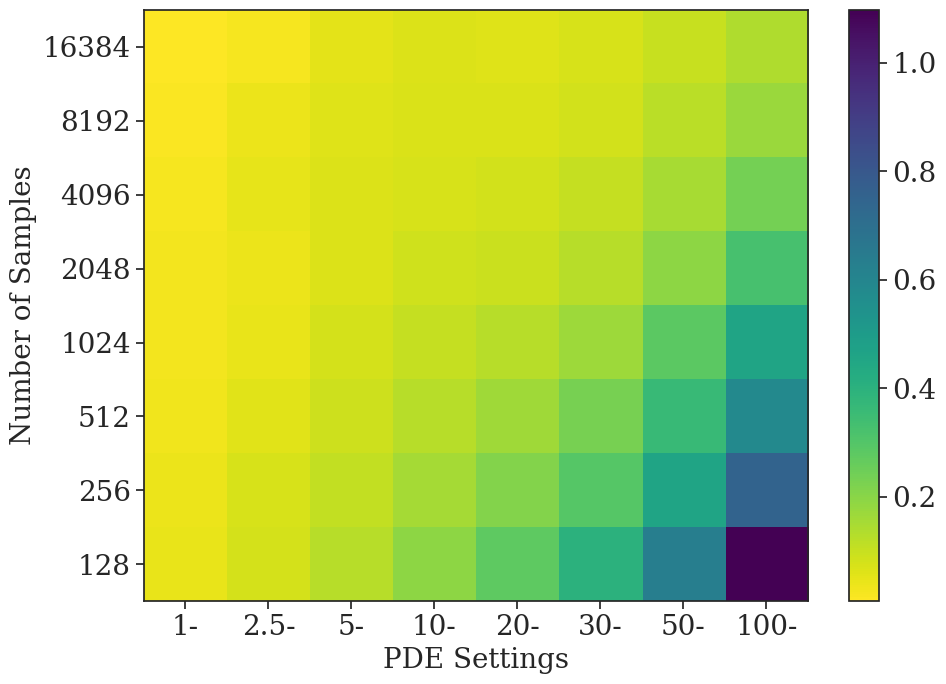

In [18]:
### 8 \times 8 grid
import numpy as np
import matplotlib.pyplot as plt

pde_settings = k_range_list
lr = lr_range[0]
## 7x7 zeros
loss = np.array([[0.0 for _ in range(len(pde_settings))] for _ in range(len(sub_sampling_range))])
print(loss.shape)

 
for k_range in k_ranges:
    pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    for subsamples in sub_sampling_range:

        if subsamples == 512:
            hyper_setting = f'bsz64_lr{lr}_subsample{subsamples}'
        elif subsamples == 1024:
            hyper_setting = f'bsz32_lr{lr}_subsample{subsamples}'
        elif subsamples == 2048:
            hyper_setting = f'bsz16_lr{lr}_subsample{subsamples}'
        elif subsamples == 4096:
            hyper_setting = f'bsz8_lr{lr}_subsample{subsamples}'
        else:
            hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsamples}'
        loss[sub_sampling_range.index(subsamples), k_ranges.index(k_range)] = exp_stats[pde_setting][hyper_setting]['test_err_mean']


from matplotlib.colors import LogNorm

plt.figure(figsize=(10, 7))
heatmap = plt.imshow(loss, aspect='auto', cmap='viridis_r', origin='lower')

cbar = plt.colorbar(heatmap)
# fontsize for cbar
cbar.ax.tick_params(labelsize=medfont)
# cbar.set_label("L2 Error", fontsize=medfont)


plt.xticks(ticks=np.arange(len(pde_settings)), labels=pde_settings, fontsize=medfont)
plt.yticks(ticks=np.arange(len(sub_sampling_range)), labels=data_number_range, fontsize=medfont)
plt.xlabel("PDE Settings", fontsize=medfont)
plt.ylabel("Number of Samples", fontsize=medfont)

# plt.title("Test", fontsize=medfont)
# for i in range(loss.shape[0]):
#     for j in range(loss.shape[1]):
#         plt.text(j, i, f'{loss[i, j]:.3f}', ha='center', va='center', color='white')
        
plt.tight_layout()
plt.savefig('/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/plots/nips_ws/test_error_fno.png', dpi=400, bbox_inches='tight')
plt.show()

(8, 8)


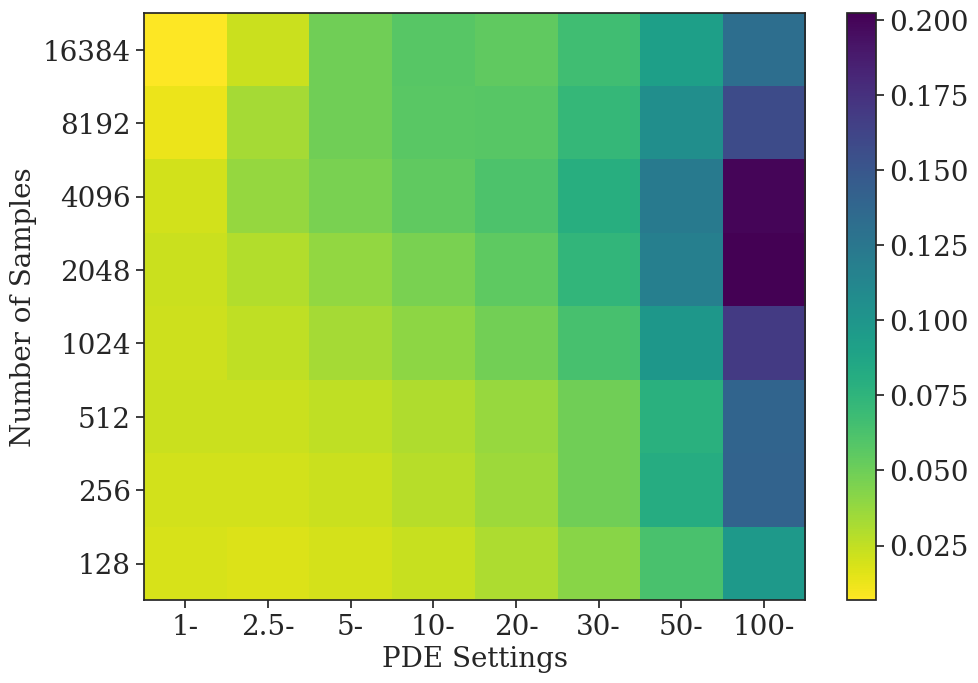

In [19]:
### 8 \times 8 grid
import numpy as np
import matplotlib.pyplot as plt

pde_settings = k_range_list
lr = lr_range[0]
## 7x7 zeros
loss = np.array([[0.0 for _ in range(len(pde_settings))] for _ in range(len(sub_sampling_range))])
print(loss.shape)

 
for k_range in k_ranges:
    pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    for subsamples in sub_sampling_range:

        if subsamples == 512:
            hyper_setting = f'bsz64_lr{lr}_subsample{subsamples}'
        elif subsamples == 1024:
            hyper_setting = f'bsz32_lr{lr}_subsample{subsamples}'
        elif subsamples == 2048:
            hyper_setting = f'bsz16_lr{lr}_subsample{subsamples}'
        elif subsamples == 4096:
            hyper_setting = f'bsz8_lr{lr}_subsample{subsamples}'
        else:
            hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsamples}'
        loss[sub_sampling_range.index(subsamples), k_ranges.index(k_range)] = exp_stats[pde_setting][hyper_setting]['train_err_mean']


from matplotlib.colors import LogNorm

plt.figure(figsize=(10, 7))
heatmap = plt.imshow(loss, aspect='auto', cmap='viridis_r', origin='lower')

cbar = plt.colorbar(heatmap)
# fontsize for cbar
cbar.ax.tick_params(labelsize=medfont)
# cbar.set_label("L2 Error", fontsize=medfont)


plt.xticks(ticks=np.arange(len(pde_settings)), labels=pde_settings, fontsize=medfont)
plt.yticks(ticks=np.arange(len(sub_sampling_range)), labels=data_number_range, fontsize=medfont)
plt.xlabel("PDE Settings", fontsize=medfont)
plt.ylabel("Number of Samples", fontsize=medfont)

# plt.title("Training", fontsize=medfont)
# for i in range(loss.shape[0]):
#     for j in range(loss.shape[1]):
#         plt.text(j, i, f'{loss[i, j]:.3f}', ha='center', va='center', color='white')
        
plt.tight_layout()
plt.savefig('/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/plots/nips_ws/train_err_fno.png', dpi=400, bbox_inches='tight')
plt.show()

### CKA / Hessian / LMC


In [9]:
hessian_dir ="/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/hessian_analysis"



In [10]:
### Layer-wise Hessian Analysis: Average Eigenvalues Across All Layers

import re
import os
import numpy as np
import matplotlib.pyplot as plt

def parse_hessian_results(file_path):
    """
    解析Hessian结果文件，提取每层的最大特征值
    """
    layer_eigenvalues = {}
    try:
        with open(file_path, 'r') as f:
            content = f.read()
            
        # 提取layerwise_results部分
        layerwise_section = content.split('layerwise_results:')[1]
        
        # 使用正则表达式提取每层的信息
        layer_pattern = r'(\w+):\s*\n\s*eigenvalues:\s*\n\s*eigenvalues: \[([0-9.]+)\]'
        matches = re.findall(layer_pattern, layerwise_section)
        
        for layer_name, eigenvalue in matches:
            layer_eigenvalues[layer_name] = float(eigenvalue)
            
    except Exception as e:
        print(f"Error parsing {file_path}: {e}")
        return {}
        
    return layer_eigenvalues

def get_hessian_avg_across_layers():
    """
    获取所有实验设置下Layer-wise Hessian的平均值
    """
    hessian_stats = {}
    
    for k_range in k_ranges:
        pde_settings = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
        hessian_stats[pde_settings] = {}
        
        for subsamples in sub_sampling_range:
            # 确定实验目录
            if subsamples == 256:
                base_dir = 'expts_eps1000'
            elif subsamples == 128:
                base_dir = 'expts_eps750'
            elif subsamples == 64:
                base_dir = 'expts_eps500'
            elif subsamples == 32:
                base_dir = 'expts_eps300'
            elif subsamples == 16:
                base_dir = 'expts_eps200'
            elif subsamples == 8:
                base_dir = 'expts_eps150'
            elif subsamples == 4:
                base_dir = 'expts_eps100'
            elif subsamples == 2:
                base_dir = 'expts_eps75'
            else:
                continue
                
            hyper_settings = f'bsz{bsz}_lr{lr_range[0]}_subsample{subsamples}'
            hessian_stats[pde_settings][hyper_settings] = {}
            
            avg_eigenvalues_by_seed = []
            last_layer_eigenvalues_by_seed = []
            
            # 遍历所有种子
            for seed in seed_range:
                hessian_file = f'{hessian_dir}/{base_dir}/{pde_settings}/hessian_analysis_pyhessian_eigenvalues_layerwise_topN1/{hyper_settings}/seed{seed}/hessian_pyhessian_eigenvalues_results.txt'
                
                if os.path.exists(hessian_file):
                    layer_eigenvalues = parse_hessian_results(hessian_file)
                    if layer_eigenvalues:
                        # 计算所有层的平均特征值
                        avg_eigenvalue = np.mean(list(layer_eigenvalues.values()))
                        avg_eigenvalues_by_seed.append(avg_eigenvalue)
                        
                        # 获取最后一层的特征值（通常是output_projection）
                        if 'output_projection' in layer_eigenvalues:
                            last_layer_eigenvalues_by_seed.append(layer_eigenvalues['output_projection'])
                        
            if avg_eigenvalues_by_seed:
                hessian_stats[pde_settings][hyper_settings]['avg_eigenvalue_mean'] = np.mean(avg_eigenvalues_by_seed)
                hessian_stats[pde_settings][hyper_settings]['avg_eigenvalue_std'] = np.std(avg_eigenvalues_by_seed)
                print(f'{pde_settings} {hyper_settings}: {np.mean(avg_eigenvalues_by_seed):.2f} ± {np.std(avg_eigenvalues_by_seed):.2f}')
            else:
                hessian_stats[pde_settings][hyper_settings]['avg_eigenvalue_mean'] = np.nan
                hessian_stats[pde_settings][hyper_settings]['avg_eigenvalue_std'] = np.nan
                print(f'{pde_settings} {hyper_settings}: No data found')
            
            # 添加最后一层的统计信息
            if last_layer_eigenvalues_by_seed:
                hessian_stats[pde_settings][hyper_settings]['last_layer_eigenvalue_mean'] = np.mean(last_layer_eigenvalues_by_seed)
                hessian_stats[pde_settings][hyper_settings]['last_layer_eigenvalue_std'] = np.std(last_layer_eigenvalues_by_seed)
            else:
                hessian_stats[pde_settings][hyper_settings]['last_layer_eigenvalue_mean'] = np.nan
                hessian_stats[pde_settings][hyper_settings]['last_layer_eigenvalue_std'] = np.nan
                
    return hessian_stats

# 获取Hessian统计数据
hessian_exp_stats = get_hessian_avg_across_layers()


poisson_scale_k1.0_2.5_val1024_1M bsz128_lr0.001_subsample256: 14716.63 ± 9615.90
poisson_scale_k1.0_2.5_val1024_1M bsz128_lr0.001_subsample128: 16315.97 ± 11468.94
poisson_scale_k1.0_2.5_val1024_1M bsz128_lr0.001_subsample64: 16850.09 ± 11093.78
poisson_scale_k1.0_2.5_val1024_1M bsz128_lr0.001_subsample32: 12389.43 ± 3264.32
poisson_scale_k1.0_2.5_val1024_1M bsz128_lr0.001_subsample16: 11575.89 ± 4275.10
poisson_scale_k1.0_2.5_val1024_1M bsz128_lr0.001_subsample8: 8930.18 ± 3526.27
poisson_scale_k1.0_2.5_val1024_1M bsz128_lr0.001_subsample4: 14841.36 ± 9195.16
poisson_scale_k1.0_2.5_val1024_1M bsz128_lr0.001_subsample2: 16028.38 ± 9811.51
poisson_scale_k2.5_5.0_val1024_1M bsz128_lr0.001_subsample256: 7997.33 ± 2987.55
poisson_scale_k2.5_5.0_val1024_1M bsz128_lr0.001_subsample128: 9126.46 ± 4283.66
poisson_scale_k2.5_5.0_val1024_1M bsz128_lr0.001_subsample64: 9875.84 ± 5082.35
poisson_scale_k2.5_5.0_val1024_1M bsz128_lr0.001_subsample32: 8082.88 ± 2138.26
poisson_scale_k2.5_5.0_val1024

Hessian matrix shape: (8, 8)


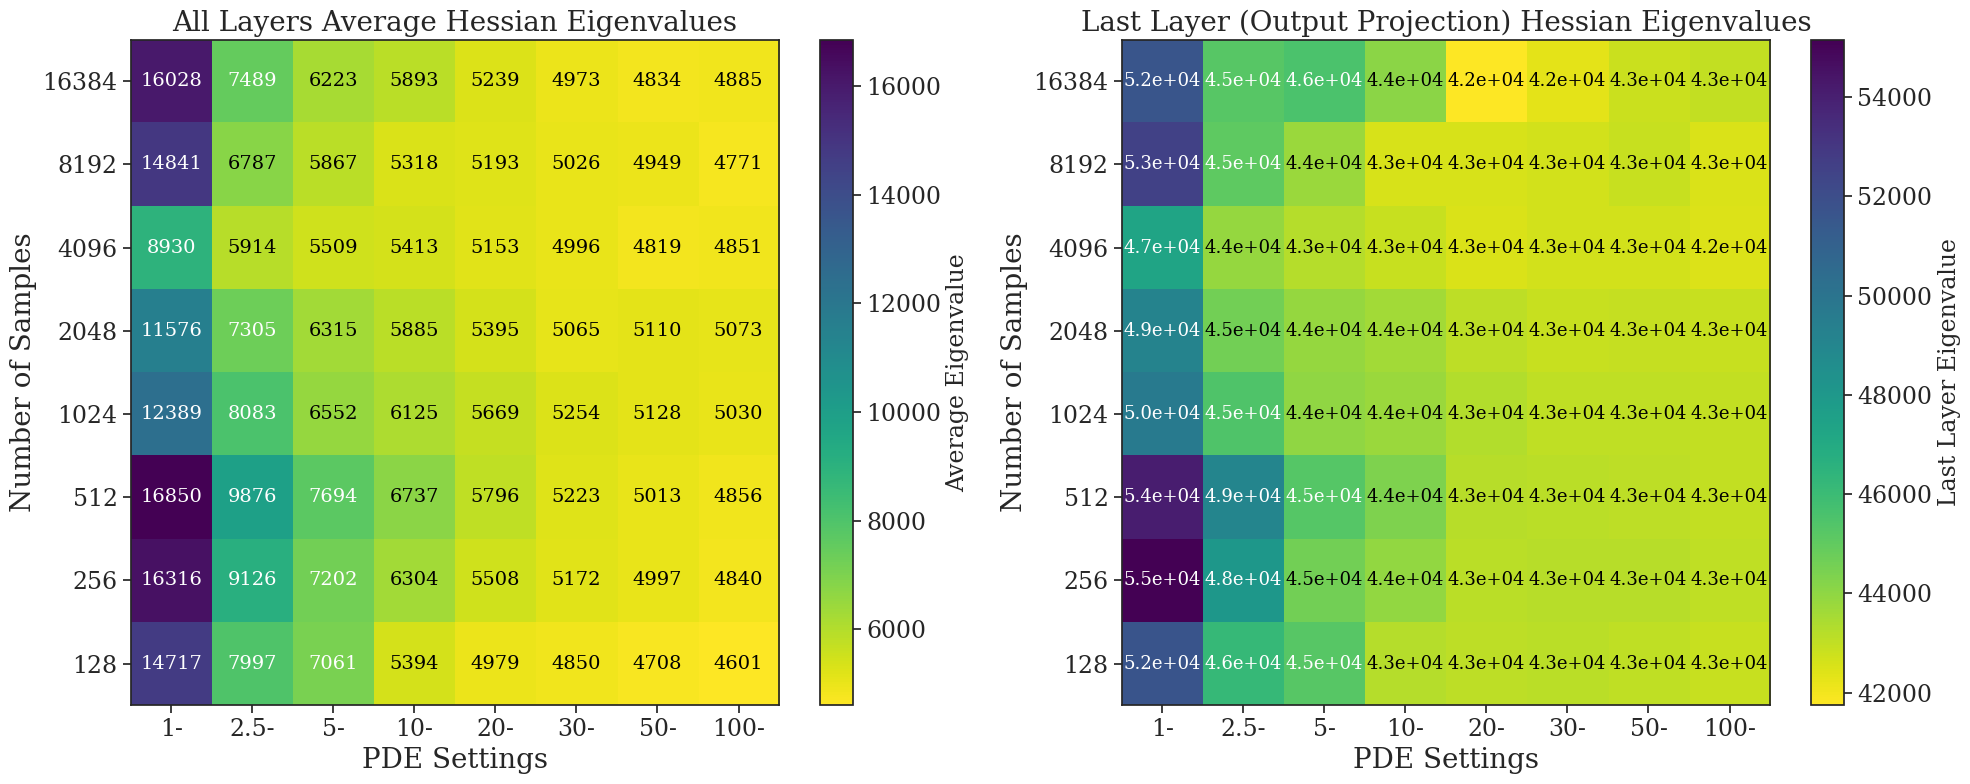


Hessian特征值统计对比:
所有层平均值:
------------------------------
最小值: 4601.28
最大值: 16850.09
平均值: 6807.40
标准差: 3045.66

最后一层特征值:
------------------------------
最小值: 41747.47
最大值: 55155.36
平均值: 44598.06
标准差: 2981.60

最后一层/所有层平均值比值: 6.55


In [11]:
### 绘制Layer-wise Hessian特征值热力图：所有层平均值 vs 最后一层

# 创建热力图数据矩阵
pde_settings = k_range_list
lr = lr_range[0]

# 所有层平均值矩阵
hessian_matrix_avg = np.array([[np.nan for _ in range(len(pde_settings))] for _ in range(len(sub_sampling_range))])
# 最后一层矩阵
hessian_matrix_last_layer = np.array([[np.nan for _ in range(len(pde_settings))] for _ in range(len(sub_sampling_range))])

print(f"Hessian matrix shape: {hessian_matrix_avg.shape}")

# 填充数据
for k_range in k_ranges:
    pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    for subsamples in sub_sampling_range:
        hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsamples}'
        
        if pde_setting in hessian_exp_stats and hyper_setting in hessian_exp_stats[pde_setting]:
            # 所有层平均值
            avg_val = hessian_exp_stats[pde_setting][hyper_setting]['avg_eigenvalue_mean']
            if not np.isnan(avg_val):
                hessian_matrix_avg[sub_sampling_range.index(subsamples), k_ranges.index(k_range)] = avg_val
            
            # 最后一层特征值
            last_val = hessian_exp_stats[pde_setting][hyper_setting]['last_layer_eigenvalue_mean']
            if not np.isnan(last_val):
                hessian_matrix_last_layer[sub_sampling_range.index(subsamples), k_ranges.index(k_range)] = last_val

# 创建并排的热力图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# 第一个子图：所有层平均值
im1 = ax1.imshow(hessian_matrix_avg, aspect='auto', cmap='viridis_r', origin='lower')
ax1.set_title("All Layers Average Hessian Eigenvalues", fontsize=medfont)
ax1.set_xlabel("PDE Settings", fontsize=medfont)
ax1.set_ylabel("Number of Samples", fontsize=medfont)
ax1.set_xticks(ticks=np.arange(len(pde_settings)))
ax1.set_xticklabels(pde_settings, fontsize=smallfont)
ax1.set_yticks(ticks=np.arange(len(sub_sampling_range)))
ax1.set_yticklabels(data_number_range, fontsize=smallfont)

# 添加颜色条
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.ax.tick_params(labelsize=smallfont)
cbar1.set_label("Average Eigenvalue", fontsize=smallfont)

# 添加数值标注
for i in range(hessian_matrix_avg.shape[0]):
    for j in range(hessian_matrix_avg.shape[1]):
        if not np.isnan(hessian_matrix_avg[i, j]):
            text = f'{hessian_matrix_avg[i, j]:.0f}'
            ax1.text(j, i, text, ha='center', va='center', 
                    color='white' if hessian_matrix_avg[i, j] > np.nanmean(hessian_matrix_avg) else 'black',
                    fontsize=smallfont-3)

# 第二个子图：最后一层
im2 = ax2.imshow(hessian_matrix_last_layer, aspect='auto', cmap='viridis_r', origin='lower')
ax2.set_title("Last Layer (Output Projection) Hessian Eigenvalues", fontsize=medfont)
ax2.set_xlabel("PDE Settings", fontsize=medfont)
ax2.set_ylabel("Number of Samples", fontsize=medfont)
ax2.set_xticks(ticks=np.arange(len(pde_settings)))
ax2.set_xticklabels(pde_settings, fontsize=smallfont)
ax2.set_yticks(ticks=np.arange(len(sub_sampling_range)))
ax2.set_yticklabels(data_number_range, fontsize=smallfont)

# 添加颜色条
cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.ax.tick_params(labelsize=smallfont)
cbar2.set_label("Last Layer Eigenvalue", fontsize=smallfont)

# 添加数值标注
for i in range(hessian_matrix_last_layer.shape[0]):
    for j in range(hessian_matrix_last_layer.shape[1]):
        if not np.isnan(hessian_matrix_last_layer[i, j]):
            # 使用科学计数法显示大数值
            if hessian_matrix_last_layer[i, j] >= 1000:
                text = f'{hessian_matrix_last_layer[i, j]:.1e}'
            else:
                text = f'{hessian_matrix_last_layer[i, j]:.0f}'
            ax2.text(j, i, text, ha='center', va='center', 
                    color='white' if hessian_matrix_last_layer[i, j] > np.nanmean(hessian_matrix_last_layer) else 'black',
                    fontsize=smallfont-4)

plt.tight_layout()
plt.savefig('/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/plots/nips_ws/hessian_comparison_all_vs_last_layer.png', 
            dpi=400, bbox_inches='tight')
plt.show()

# 打印统计信息对比
print("\nHessian特征值统计对比:")
print("=" * 60)

# 所有层平均值统计
valid_avg = hessian_matrix_avg[~np.isnan(hessian_matrix_avg)]
print("所有层平均值:")
print("-" * 30)
if len(valid_avg) > 0:
    print(f"最小值: {np.min(valid_avg):.2f}")
    print(f"最大值: {np.max(valid_avg):.2f}")
    print(f"平均值: {np.mean(valid_avg):.2f}")
    print(f"标准差: {np.std(valid_avg):.2f}")
else:
    print("没有找到有效数据")

print()

# 最后一层统计
valid_last = hessian_matrix_last_layer[~np.isnan(hessian_matrix_last_layer)]
print("最后一层特征值:")
print("-" * 30)
if len(valid_last) > 0:
    print(f"最小值: {np.min(valid_last):.2f}")
    print(f"最大值: {np.max(valid_last):.2f}")
    print(f"平均值: {np.mean(valid_last):.2f}")
    print(f"标准差: {np.std(valid_last):.2f}")
    
    # 计算比值
    if len(valid_avg) > 0:
        ratio_mean = np.mean(valid_last) / np.mean(valid_avg)
        print(f"\n最后一层/所有层平均值比值: {ratio_mean:.2f}")
else:
    print("没有找到有效数据")


分析设置: poisson_scale_k20.0_30.0_val1024_1M, bsz128_lr0.001_subsample256


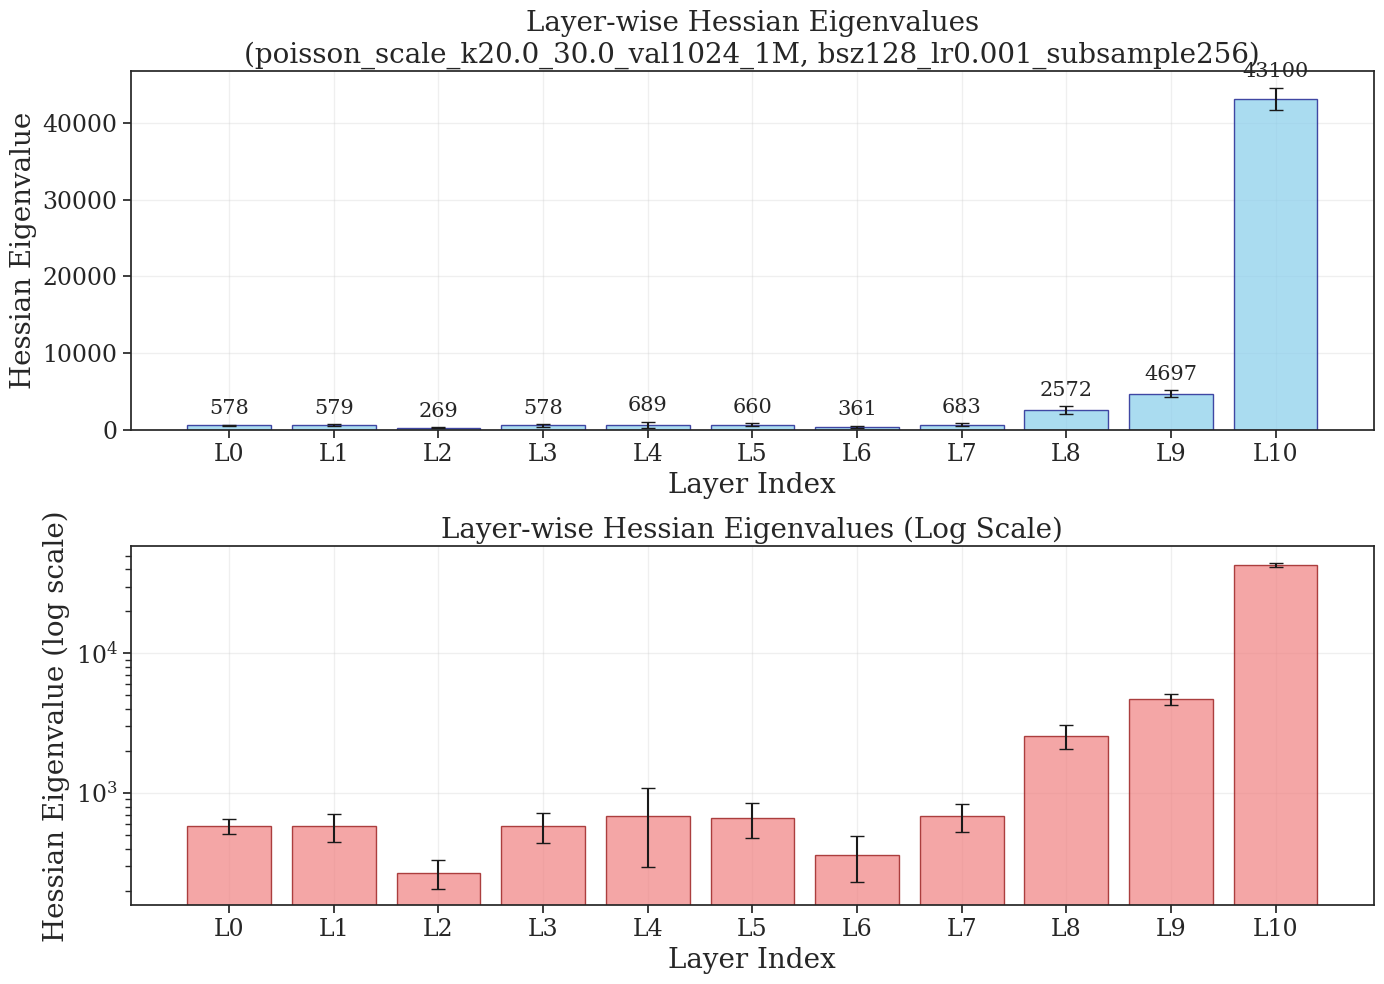


层级Hessian特征值详细信息:
--------------------------------------------------
Layer  0 (input_projection    ):   577.80 ±  71.06
Layer  1 (spectral_conv_0     ):   578.62 ± 134.03
Layer  2 (spectral_conv_1     ):   269.43 ±  63.76
Layer  3 (spectral_conv_2     ):   577.97 ± 142.92
Layer  4 (spectral_conv_3     ):   688.75 ± 391.87
Layer  5 (skip_connection_0   ):   659.87 ± 182.16
Layer  6 (skip_connection_1   ):   360.57 ± 131.55
Layer  7 (skip_connection_2   ):   682.65 ± 156.80
Layer  8 (skip_connection_3   ):  2572.42 ± 504.04
Layer  9 (hidden_projection   ):  4696.86 ± 438.97
Layer 10 (output_projection   ): 43099.67 ± 1439.14

所有层平均值: 4978.60
所有层标准差: 12121.32


In [12]:
### 详细分析：不同层的Hessian特征值分布

def get_layerwise_hessian_details():
    """
    获取每一层的详细Hessian特征值数据
    """
    layer_details = {}
    
    # 选择一个代表性的实验设置进行详细分析
    k_range = k_ranges[4]  # 选择中间的k值范围
    subsamples = 256  # 选择最多的样本数
    
    pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    base_dir = 'expts_eps1000'
    hyper_setting = f'bsz{bsz}_lr{lr_range[0]}_subsample{subsamples}'
    
    print(f"分析设置: {pde_setting}, {hyper_setting}")
    
    all_seeds_data = []
    
    for seed in seed_range:
        hessian_file = f'{hessian_dir}/{base_dir}/{pde_setting}/hessian_analysis_pyhessian_eigenvalues_layerwise_topN1/{hyper_setting}/seed{seed}/hessian_pyhessian_eigenvalues_results.txt'
        
        if os.path.exists(hessian_file):
            layer_eigenvalues = parse_hessian_results(hessian_file)
            if layer_eigenvalues:
                all_seeds_data.append(layer_eigenvalues)
    
    if all_seeds_data:
        # 获取所有层的名称
        layer_names = list(all_seeds_data[0].keys())
        
        # 为每一层计算统计信息
        for layer_name in layer_names:
            layer_values = [data[layer_name] for data in all_seeds_data if layer_name in data]
            if layer_values:
                layer_details[layer_name] = {
                    'mean': np.mean(layer_values),
                    'std': np.std(layer_values),
                    'values': layer_values
                }
    
    return layer_details, pde_setting, hyper_setting

# 获取层级详细数据
layer_details, analyzed_pde, analyzed_hyper = get_layerwise_hessian_details()

if layer_details:
    # 绘制条形图显示每层的平均特征值
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    layer_names = list(layer_details.keys())
    mean_values = [layer_details[name]['mean'] for name in layer_names]
    std_values = [layer_details[name]['std'] for name in layer_names]
    
    # 第一个子图：条形图
    bars = ax1.bar(range(len(layer_names)), mean_values, yerr=std_values, 
                   capsize=5, alpha=0.7, color='skyblue', edgecolor='navy')
    ax1.set_xlabel('Layer Index', fontsize=medfont)
    ax1.set_ylabel('Hessian Eigenvalue', fontsize=medfont)
    ax1.set_title(f'Layer-wise Hessian Eigenvalues\n({analyzed_pde}, {analyzed_hyper})', fontsize=medfont)
    ax1.set_xticks(range(len(layer_names)))
    ax1.set_xticklabels([f'L{i}' for i in range(len(layer_names))], fontsize=smallfont)
    ax1.tick_params(axis='y', labelsize=smallfont)
    ax1.grid(True, alpha=0.3)
    
    # 添加数值标签
    for i, (mean_val, std_val) in enumerate(zip(mean_values, std_values)):
        ax1.text(i, mean_val + std_val + max(mean_values)*0.02, f'{mean_val:.0f}', 
                ha='center', va='bottom', fontsize=smallfont-2)
    
    # 第二个子图：对数尺度
    ax2.bar(range(len(layer_names)), mean_values, yerr=std_values, 
            capsize=5, alpha=0.7, color='lightcoral', edgecolor='darkred')
    ax2.set_xlabel('Layer Index', fontsize=medfont)
    ax2.set_ylabel('Hessian Eigenvalue (log scale)', fontsize=medfont)
    ax2.set_title('Layer-wise Hessian Eigenvalues (Log Scale)', fontsize=medfont)
    ax2.set_xticks(range(len(layer_names)))
    ax2.set_xticklabels([f'L{i}' for i in range(len(layer_names))], fontsize=smallfont)
    ax2.tick_params(axis='y', labelsize=smallfont)
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/plots/nips_ws/hessian_layerwise_details.png', 
                dpi=400, bbox_inches='tight')
    plt.show()
    
    # 打印层级信息
    print("\n层级Hessian特征值详细信息:")
    print("-" * 50)
    for i, (layer_name, details) in enumerate(layer_details.items()):
        print(f"Layer {i:2d} ({layer_name:20s}): {details['mean']:8.2f} ± {details['std']:6.2f}")
    
    print(f"\n所有层平均值: {np.mean(mean_values):.2f}")
    print(f"所有层标准差: {np.std(mean_values):.2f}")
else:
    print("未找到Hessian数据！")
